# Fase 5 — Modelli

Tre livelli, ciascuno con una funzione argomentativa precisa:

1. **Baseline maggioritaria** — il pavimento sotto cui non si puo' stare.
2. **Logistica su feature stilometriche** — il modello principale. Scelto
   perche' i coefficienti sono leggibili: senza interpretabilita' l'analisi
   dei falsi positivi (Fase 6) sarebbe impossibile.
3. **TF-IDF + logistica** — confronto fra segnale *stilistico* e segnale
   *lessicale*.

Previsione registrata prima dell'esecuzione: TF-IDF dovrebbe fare **meglio**
in-domain e **peggio** fuori dominio, perche' impara anche il lessico
tematico (cfr. Fase 3: `financial` discriminava solo dentro il dominio
finance).

## 0. Setup

In [1]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RADICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURE = RADICE / "results" / "figures"
TABELLE = RADICE / "results" / "tables"
FIGURE.mkdir(parents=True, exist_ok=True)
TABELLE.mkdir(parents=True, exist_ok=True)

SEED = 42
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

print("Radice:", RADICE)

Radice: /Users/costanzastassi/Desktop/mgt-stylometry


I moduli in `src/` hanno prefissi numerici, quindi non sono importabili
con `import`. Si caricano per percorso.

In [2]:
def carica_modulo(nome_file: str, alias: str):
    """Carica un modulo da src/ anche se il nome inizia con una cifra."""
    percorso = RADICE / "src" / nome_file
    if not percorso.exists():
        candidati = sorted(p.name for p in (RADICE / "src").glob("*.py"))
        raise FileNotFoundError(f"{nome_file} non trovato. In src/: {candidati}")
    spec = importlib.util.spec_from_file_location(alias, percorso)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[alias] = modulo
    spec.loader.exec_module(modulo)
    return modulo

# Nomi dei moduli presenti in src/
M = carica_modulo("models.py", "modelli")
E = carica_modulo("evaluation.py", "valutazione")
print("Moduli caricati")

Moduli caricati


In [3]:
df = pd.read_parquet(RADICE / "data" / "processed" / "hc3_features.parquet")
COLS = M.colonne_feature(df)

print(f"{len(df)} righe, {df['question_id'].nunique()} coppie")
print(f"{len(COLS)} feature")
print(COLS)

19980 righe, 9990 coppie
30 feature
['lung_frase_media', 'tripletta_per_100parole', 'em_dash_per_100parole', 'en_dash_per_100parole', 'lung_frase_std', 'lung_parola_media', 'n_frasi', 'mattr', 'hapax_ratio', 'entropia', 'prof_albero_media', 'subordinate_per_frase', 'coordinate_per_frase', 'ratio_connettivi', 'ratio_hedging', 'ratio_pron_prima_persona', 'pos_noun', 'pos_verb', 'pos_adj', 'pos_adv', 'pos_pron', 'pos_adp', 'pos_cconj', 'pos_sconj', 'punt_per_100parole_virgola', 'punt_per_100parole_puntovirgola', 'punt_per_100parole_duepunti', 'punt_per_100parole_parentesi', 'punt_per_100parole_esclamativo', 'punt_per_100parole_interrogativo']


## 1. Split

Lo split e' **per `question_id`**: le due risposte alla stessa domanda devono
finire nello stesso lato. Altrimenti il modello vedrebbe in addestramento la
risposta umana a una domanda e in test quella generata sulla stessa domanda,
imparando l'argomento invece dello stile.

Si costruiscono tre partizioni: train, validation (per l'eventuale taratura
degli iperparametri del modello) e test, quest'ultimo toccato una volta
sola alla fine.

In [4]:
train_completo, test = M.split_per_domanda(df, test_size=0.25)
train, valid = M.split_per_domanda(train_completo, test_size=0.20)

for nome, parte in [("train", train), ("valid", valid), ("test", test)]:
    print(f"{nome:6s} {len(parte):6d} righe  "
          f"{parte['question_id'].nunique():5d} coppie  "
          f"bilanciamento={parte['label'].mean():.3f}")

# Controllo: nessun question_id condiviso fra le partizioni
assert not (set(train.question_id) & set(test.question_id))
assert not (set(valid.question_id) & set(test.question_id))
assert not (set(train.question_id) & set(valid.question_id))
print("\nNessuna sovrapposizione fra le partizioni")

train   11986 righe   5993 coppie  bilanciamento=0.500
valid    2998 righe   1499 coppie  bilanciamento=0.500
test     4996 righe   2498 coppie  bilanciamento=0.500

Nessuna sovrapposizione fra le partizioni


In [5]:
# I domini restano rappresentati in modo simile nelle tre partizioni?
pd.DataFrame({
    "train": train["domain"].value_counts(normalize=True),
    "valid": valid["domain"].value_counts(normalize=True),
    "test": test["domain"].value_counts(normalize=True),
}).round(3)

,train,valid,test
domain,,,
finance,0.199,0.209,0.209
medicine,0.041,0.053,0.045
reddit_eli5,0.704,0.692,0.692
wiki_csai,0.056,0.046,0.054


## 2. Baseline

Predice sempre la classe maggioritaria. Con classi bilanciate deve dare
accuratezza circa 0.50: e' il riferimento rispetto a cui ogni altro numero
va letto.

In [6]:
base = M.modello_baseline()
base.fit(train[COLS], train["label"])
pred_base = base.predict(test[COLS])

ris_base = E.valuta(test["label"], pred_base, nome="baseline")
ris_base

{'modello': 'baseline',
 'accuracy': 0.5,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'fpr': np.float64(0.0),
 'n_falsi_positivi': 0,
 'n_falsi_negativi': 2498}

## 3. Modello stilometrico

Regressione logistica su feature interpretabili, con standardizzazione
obbligatoria: le scale vanno da 0.001 (`ratio_connettivi`) a oltre 30
(`punt_per_100parole_virgola`), e senza normalizzare i coefficienti non
sarebbero confrontabili.

In [7]:
stilo = M.modello_stilometrico()
stilo.fit(train[COLS], train["label"])

pred_stilo = stilo.predict(test[COLS])
prob_stilo = stilo.predict_proba(test[COLS])[:, 1]

ris_stilo = E.valuta(test["label"], pred_stilo, prob_stilo, nome="stilometrico")
ris_stilo

{'modello': 'stilometrico',
 'accuracy': 0.9191353082465973,
 'precision': 0.9208199356913184,
 'recall': 0.9171337069655725,
 'f1': 0.918973124749298,
 'fpr': np.float64(0.0788630904723779),
 'n_falsi_positivi': 197,
 'n_falsi_negativi': 207,
 'auroc': 0.9706931277608155}

### Taratura di `C`

Unico iperparametro tarato, e solo sul **validation set**. I parametri di
preprocessing (soglie di lunghezza, tolleranza di appaiamento) non si
ottimizzano: definiscono il campione, non il modello.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

righe = []
for C in [0.01, 0.1, 1.0, 10.0]:
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C, max_iter=2000, random_state=SEED),
    )
    m.fit(train[COLS], train["label"])
    p = m.predict(valid[COLS])
    pr = m.predict_proba(valid[COLS])[:, 1]
    righe.append({"C": C, **E.valuta(valid["label"], p, pr, nome=f"C={C}")})

taratura = pd.DataFrame(righe)[["C", "accuracy", "auroc", "fpr"]]
taratura

,C,accuracy,auroc,fpr
0,0.01,0.90994,0.963310,0.102068
1,0.10,0.90994,0.964216,0.097398
2,1.00,0.90994,0.964403,0.096731
3,10.00,0.90994,0.964428,0.096731


Se le differenze fra i valori di `C` sono trascurabili (sotto 0.01 di
AUROC), si tiene `C=1.0`, il default: introdurre una scelta non necessaria
aggiungerebbe un parametro da giustificare senza guadagno.

## 4. TF-IDF

Stesso classificatore, feature diverse: unigrammi e bigrammi al posto dei
tratti stilistici. Serve a quantificare quanto del segnale sia lessicale.

In [9]:
tfidf = M.modello_tfidf()
tfidf.fit(train["text"], train["label"])

pred_tfidf = tfidf.predict(test["text"])
prob_tfidf = tfidf.predict_proba(test["text"])[:, 1]

ris_tfidf = E.valuta(test["label"], pred_tfidf, prob_tfidf, nome="tfidf")
ris_tfidf

{'modello': 'tfidf',
 'accuracy': 0.9707766212970377,
 'precision': 0.9734299516908212,
 'recall': 0.9679743795036029,
 'f1': 0.9706945002007226,
 'fpr': np.float64(0.02642113690952762),
 'n_falsi_positivi': 66,
 'n_falsi_negativi': 80,
 'auroc': 0.9961758037334593}

## 5. Confronto

`fpr` (tasso di falsi positivi) e' la metrica che conta nel caso d'uso
reale: il costo di accusare un testo umano non e' simmetrico a quello di
non riconoscere un testo generato.

In [10]:
confronto = pd.DataFrame([ris_base, ris_stilo, ris_tfidf])
colonne = ["modello", "accuracy", "precision", "recall", "f1", "fpr",
           "auroc", "n_falsi_positivi", "n_falsi_negativi"]
confronto = confronto[[c for c in colonne if c in confronto.columns]]
confronto.to_csv(TABELLE / "metriche_indomain.csv", index=False)
confronto.round(4)

,modello,accuracy,precision,recall,f1,fpr,auroc,n_falsi_positivi,n_falsi_negativi
0,baseline,0.5000,0.0000,0.0000,0.0000,0.0000,NaN,0,2498
1,stilometrico,0.9191,0.9208,0.9171,0.9190,0.0789,0.9707,197,207
2,tfidf,0.9708,0.9734,0.9680,0.9707,0.0264,0.9962,66,80


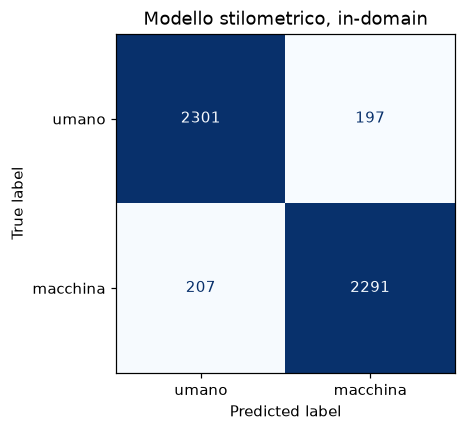

In [11]:
E.salva_matrice_confusione(
    test["label"], pred_stilo,
    FIGURE / "04_confusione_stilometrico.png",
    "Modello stilometrico, in-domain",
)
E.salva_matrice_confusione(
    test["label"], pred_tfidf,
    FIGURE / "05_confusione_tfidf.png",
    "TF-IDF, in-domain",
)

fig, ax = plt.subplots(figsize=(4.5, 4))
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    test["label"], pred_stilo,
    display_labels=["umano", "macchina"],
    cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Modello stilometrico, in-domain")
plt.show()

## 6. Curve ROC

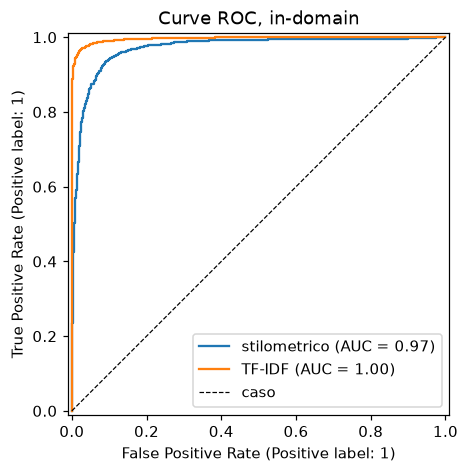

In [12]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(5, 4.5))
RocCurveDisplay.from_predictions(test["label"], prob_stilo,
                                 name="stilometrico", ax=ax)
RocCurveDisplay.from_predictions(test["label"], prob_tfidf,
                                 name="TF-IDF", ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="caso")
ax.set_title("Curve ROC, in-domain")
ax.legend()
fig.savefig(FIGURE / "06_roc_indomain.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Coefficienti

Prima lettura dei pesi. L'analisi completa e' in Fase 6, ma qui si verifica
subito la previsione registrata alla fine della Fase 4.

Attenzione: le medie marginali per classe e i coefficienti di una
regressione multivariata **non devono** coincidere. I secondi sono al netto
delle altre variabili, quindi una feature molto correlata con un'altra puo'
ricevere peso basso pur avendo una media molto diversa fra le classi. Se
l'ordine si discosta dalla previsione, non e' un errore: e' informazione.

In [13]:
coef = pd.DataFrame({
    "feature": COLS,
    "peso": stilo.named_steps["logisticregression"].coef_[0],
}).sort_values("peso")

coef["direzione"] = np.where(coef["peso"] > 0, "macchina", "umano")
coef["peso_assoluto"] = coef["peso"].abs()
coef.to_csv(TABELLE / "coefficienti_stilometrico.csv", index=False)

print("--- Spingono verso UMANO")
display(coef.head(8)[["feature", "peso"]])
print("--- Spingono verso MACCHINA")
display(coef.tail(8)[["feature", "peso"]].iloc[::-1])

--- Spingono verso UMANO


,feature,peso
8,hapax_ratio,-2.061290
6,n_frasi,-1.107509
27,punt_per_100parole_parentesi,-1.012225
4,lung_frase_std,-0.959872
25,punt_per_100parole_puntovirgola,-0.870789
19,pos_adv,-0.764530
7,mattr,-0.523140
12,coordinate_per_frase,-0.465843


--- Spingono verso MACCHINA


,feature,peso
22,pos_cconj,1.105113
10,prof_albero_media,0.822003
14,ratio_hedging,0.573182
11,subordinate_per_frase,0.534597
28,punt_per_100parole_esclamativo,0.458566
13,ratio_connettivi,0.455871
18,pos_adj,0.320825
17,pos_verb,0.281199


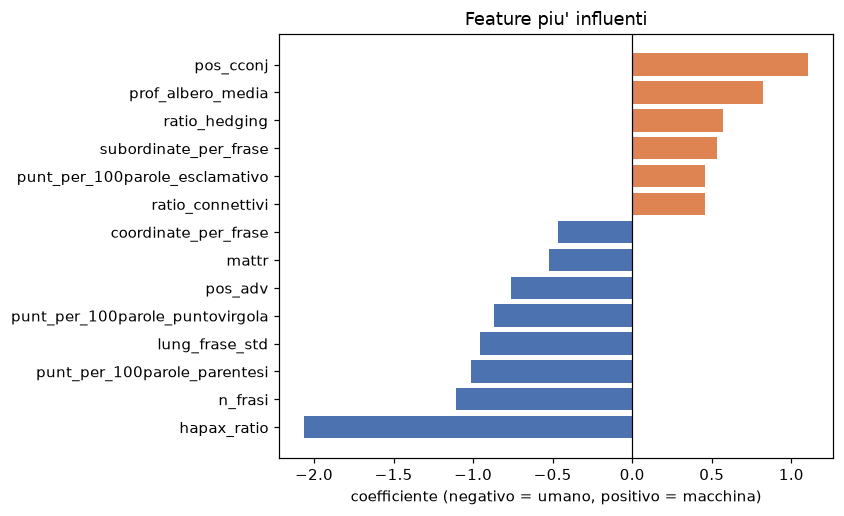

In [14]:
top = coef.nlargest(14, "peso_assoluto").sort_values("peso")
colori = ["#4C72B0" if p < 0 else "#DD8452" for p in top["peso"]]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.barh(top["feature"], top["peso"], color=colori)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("coefficiente (negativo = umano, positivo = macchina)")
ax.set_title("Feature piu' influenti")
fig.savefig(FIGURE / "07_coefficienti.png", dpi=150, bbox_inches="tight")
plt.show()

### Verifica della previsione

Previsione registrata in Fase 4:

- verso **macchina**: `ratio_connettivi`, `tripletta_per_100parole`,
  `ratio_hedging`, `coordinate_per_frase`
- verso **umano**: `punt_per_100parole_puntovirgola`,
  `em_dash_per_100parole`, `punt_per_100parole_parentesi`,
  `ratio_pron_prima_persona`

La cella seguente commenta l'esito, scritto **dopo** aver guardato i
coefficienti e senza modificare la previsione.

In [15]:
previsione = {
    "macchina": ["ratio_connettivi", "tripletta_per_100parole",
                 "ratio_hedging", "coordinate_per_frase"],
    "umano": ["punt_per_100parole_puntovirgola", "em_dash_per_100parole",
              "punt_per_100parole_parentesi", "ratio_pron_prima_persona"],
}

verifica = []
for direzione, feature in previsione.items():
    for f in feature:
        riga = coef[coef["feature"] == f]
        if riga.empty:
            verifica.append({"feature": f, "prevista": direzione,
                             "osservata": "assente", "peso": np.nan})
            continue
        verifica.append({
            "feature": f,
            "prevista": direzione,
            "osservata": riga["direzione"].iloc[0],
            "peso": riga["peso"].iloc[0],
            "rango_assoluto": int(
                coef["peso_assoluto"].rank(ascending=False)[riga.index[0]]
            ),
        })

verifica = pd.DataFrame(verifica)
verifica["conferma"] = verifica["prevista"] == verifica["osservata"]
verifica.to_csv(TABELLE / "verifica_previsione.csv", index=False)
verifica

,feature,prevista,osservata,peso,rango_assoluto,conferma
0,ratio_connettivi,macchina,macchina,0.455871,14,True
1,tripletta_per_100parole,macchina,macchina,0.203732,22,True
2,ratio_hedging,macchina,macchina,0.573182,9,True
3,coordinate_per_frase,macchina,umano,-0.465843,12,False
4,punt_per_100parole_puntovirgola,umano,umano,-0.870789,6,True
5,em_dash_per_100parole,umano,umano,-0.283090,17,True
6,punt_per_100parole_parentesi,umano,umano,-1.012225,4,True
7,ratio_pron_prima_persona,umano,umano,-0.326303,15,True


In [ ]:
# Commento alle discrepanze fra previsione e coefficienti.
commento = """
Confermate: 7 previsioni su 8.
- verso macchina: ratio_connettivi, tripletta_per_100parole, ratio_hedging;
- verso umano: punt_per_100parole_puntovirgola, em_dash_per_100parole,
  punt_per_100parole_parentesi, ratio_pron_prima_persona.

Smentite: 1.
- coordinate_per_frase era prevista verso macchina (media 1.19 contro 0.80
  nei testi umani), ma riceve peso -0.47, cioe' verso umano.

Spiegazione possibile (correlazioni fra feature, effetti di soppressione):
coordinate_per_frase e pos_cconj misurano quasi la stessa cosa (correlazione
0.72). La regressione assegna a pos_cconj il segnale condiviso (+1.11, il
coefficiente positivo piu' alto), e a coordinate_per_frase resta solo la parte
che pos_cconj non spiega, che va nella direzione opposta. I coefficienti di una
regressione multivariata sono al netto delle altre variabili e non coincidono
con le differenze fra le medie: le due feature vanno lette insieme.
"""
print(commento)


Confermate: 7 previsioni su 8.
- verso macchina: ratio_connettivi, tripletta_per_100parole, ratio_hedging;
- verso umano: punt_per_100parole_puntovirgola, em_dash_per_100parole,
  punt_per_100parole_parentesi, ratio_pron_prima_persona.

Smentite: 1.
- coordinate_per_frase era prevista verso macchina (media 1.19 contro 0.80
  nei testi umani), ma riceve peso -0.47, cioe' verso umano.

Spiegazione possibile (correlazioni fra feature, effetti di soppressione):
coordinate_per_frase e pos_cconj misurano quasi la stessa cosa (correlazione
0.72). La regressione assegna a pos_cconj il segnale condiviso (+1.11, il
coefficiente positivo piu' alto), e a coordinate_per_frase resta solo la parte
che pos_cconj non spiega, che va nella direzione opposta. I coefficienti di una
regressione multivariata sono al netto delle altre variabili e non coincidono
con le differenze fra le medie: le due feature vanno lette insieme.



## 8. Nota di lettura

Se l'AUROC del modello stilometrico supera 0.98, fermarsi e cercare un
leakage residuo: con feature cosi' generiche un valore del genere e'
sospetto piu' che soddisfacente.

Il numero che conta per il progetto non e' l'accuratezza ma **quanti falsi
positivi** ci sono e **chi sono** — la Fase 6 parte da qui.